Here , we will do visualization to the scraped news dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("scraped_news.csv")  # reading scraped dataset

In [ ]:
sns.set_style("whitegrid")   # visualization settings
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
df.head(1)

,id,news_url,title,tweet_ids,label,clean_title,full_text
0,gossipcop-883103,https://www.seventeen.com/celebrity/celebrity-...,Khloe Kardashian and Tristan Thompson Relation...,912862138867355648\t912863141561692160\t912863...,0,khloe kardashian tristan thompson relationship...,Seventeen picks products that we think you'll ...


In [ ]:
print(f"Total number of data: {len(df)}")  # total rows

Total number of data: 11125


We will add some columns for feature engineering. We need to analyze and get something from the texts. Like sentiment, it shows us how emotionally the new is. It will help us differ news and making the decision in training and testing.

In [ ]:
def analyze_text_style(text):  # function for feature engineering
    text = str(text)  # ensuring that it is string
    if not isinstance(text, str) or len(text) < 5:
        return pd.Series([0, 0, 0, 0, 0, 0])

    words = text.split()  # to determine word count
    num_words = len(words) if len(words) > 0 else 1  # calculating total num of words

    # Sentiment Analysis
    try:
        blob = TextBlob(text)
        # Polarity: Measures emotionality  (between - 1.0 and + 1.0)
        sentiment = blob.sentiment.polarity  # emotion
        # Subjectivity: Measures objectivity (between - 1.0 and + 1.0)
        subjectivity = blob.sentiment.subjectivity # being subjective
    except:
        sentiment, subjectivity = 0, 0

    # Lexical Diversity
    unique_words = len(set(words))
    lexical_div = unique_words / num_words # unique words over num of words gives us the variety / diversity

    # Uppercase Ratio
    # quantifying the usage of capital letters in the news
    caps_count = sum(1 for c in text if c.isupper())
    caps_ratio = caps_count / len(text) if len(text) > 0 else 0  # count of upcase over total length

    # Punctuation Analysis (sensationalism)
    exclamation_count = text.count('!')

    # Return all extracted features as a Pandas Series for dataframe integration
    return pd.Series([num_words, sentiment, subjectivity, lexical_div, caps_ratio, exclamation_count])

In [ ]:
df[['word_count', 'sentiment', 'subjectivity', 'lexical_div', 'caps_ratio', 'excl_count']] = df['full_text'].apply(analyze_text_style) # applying the function and creating columns

print("Function Completed. Columns are added.")
display(df.head(10))

Function Completed. Columns are added.


,id,news_url,title,tweet_ids,label,clean_title,full_text,word_count,sentiment,subjectivity,lexical_div,caps_ratio,excl_count
0,gossipcop-883103,https://www.seventeen.com/celebrity/celebrity-...,Khloe Kardashian and Tristan Thompson Relation...,912862138867355648\t912863141561692160\t912863...,0,khloe kardashian tristan thompson relationship...,Seventeen picks products that we think you'll ...,17159.0,0.162199,0.483160,0.227577,0.035920,52.0
1,gossipcop-846137,https://en.wikipedia.org/wiki/Lindsey_Morgan,Lindsey Morgan,857349595583713283\t857349853327745024\t857350...,0,lindsey morgan,American actress (born 1990)\n\nLindsey Marie ...,757.0,0.101347,0.384722,0.577279,0.049601,1.0
2,gossipcop-890737,https://www.bustle.com/p/why-did-nene-leakes-r...,Why Did NeNe Leakes Return To 'The Real Housew...,925546089918484480\t925547217783439360\t925548...,0,nene leakes return real housewives atlanta sea...,Let's face it. The franchise just hasn't been ...,621.0,0.083881,0.427886,0.584541,0.046380,1.0
3,gossipcop-861692,https://www.brides.com/story/stevie-wonder-wed...,Stevie Wonder Quietly Marries Longtime Girlfri...,887864669821710337\t887864972209868800\t887864...,0,stevie wonder quietly marries longtime girlfri...,When Sophie Turner and Joe Jonas met through m...,1963.0,0.162712,0.417591,0.491085,0.040062,19.0
4,gossipcop-897537,https://mashable.com/2017/11/04/chrissy-teigen...,19 times Chrissy Teigen got hilariously angry ...,936689977404116993\t936690224578551808\t936690...,0,times chrissy teigen got hilariously angry stu...,Sam Haysom is the Deputy UK Editor for Mashabl...,603.0,0.121010,0.558725,0.671642,0.067164,1.0
5,gossipcop-888997,http://toofab.com/2017/10/24/matt-damon-uses-g...,Matt Damon Uses George Clooney's Twins to Esca...,922817217540034560\t922817296501837826\t922817...,0,matt damon uses george clooneys twins escalate...,YouTube\n\nGeorge Clooney's kids got in on Mat...,165.0,0.144708,0.372359,0.769697,0.040609,1.0
6,gossipcop-918824,https://www.elle.com/uk/life-and-culture/cultu...,Khloé Kardashian Reveals She Might Give Her Ba...,971133333253033991\t971133897097523201\t971134...,0,khloé kardashian reveals might give baby girl ...,We're just going to put it out there – we've b...,282.0,0.034564,0.557576,0.691489,0.046894,0.0
7,gossipcop-943405,https://punkee.com.au/ed-sheeran-wax-figure/50451,This Ed Sheeran Wax Figure Is Creepily Spot-On...,1006584952979222528\t1006585633295351808\t1006...,0,sheeran wax figure creepily spoton terrified,"This Ed Sheeran Wax Figure Is So Spot-On, It’s...",166.0,0.030409,0.574635,0.765060,0.064481,1.0
8,gossipcop-938508,https://www.usatoday.com/story/life/people/201...,The best burns from Julia Louis-Dreyfus' Mark ...,999404357312540673\t999404367735328770,0,best burns julia louisdreyfus mark twain prize...,WASHINGTON – Julia Louis-Dreyfus walked away w...,882.0,0.101528,0.493662,0.598639,0.043948,1.0
9,gossipcop-925534,https://people.com/health/cynthia-bailey-surge...,Cynthia Bailey Underwent Surgery to Remove a L...,981989132351270913\t981989164697772038\t981989...,0,cynthia bailey underwent surgery remove lipoma...,Cynthia Bailey is back at home recovering afte...,289.0,0.035031,0.298457,0.622837,0.023926,0.0


now we got the word count, sentiment,subjectivity,lexical_div,caps_ratio_excl_count

In [ ]:
display(df["full_text"][156]) # sonradan manipulation a ekle

'NORRISTOWN, Pa. -- The judge in Bill Cosby\'s sexual assault trial declared a mistrial Saturday after jurors said they were deadlocked after five days of deliberations.\n\nThe jury informed Judge Steven T. O\'Neill it was "deadlocked on all counts" in a note Saturday morning. O\'Neill asked jurors if they were "hopeless[ly] deadlocked," and each stood and agreed they were, CBS News\' Vidya Singh reports.\n\nO\'Neill called the jury\'s effort "one of the more courageous acts, one of the more selfless acts that I\'ve seen in the justice system."\n\n"I feel bad for all of you. I really do," he said.\n\nCosby remains free on bail.\n\nMontgomery County District Attorney Kevin Steele said he will immediately retry the case.\n\n"We will evaluate and review our case. We will take a hard look at everything involved, and then we will retry it," Steele said at a press conference Saturday morning. "As I said in court, our plan is to move this case forward as soon as possible."\n\nA courtroom sket

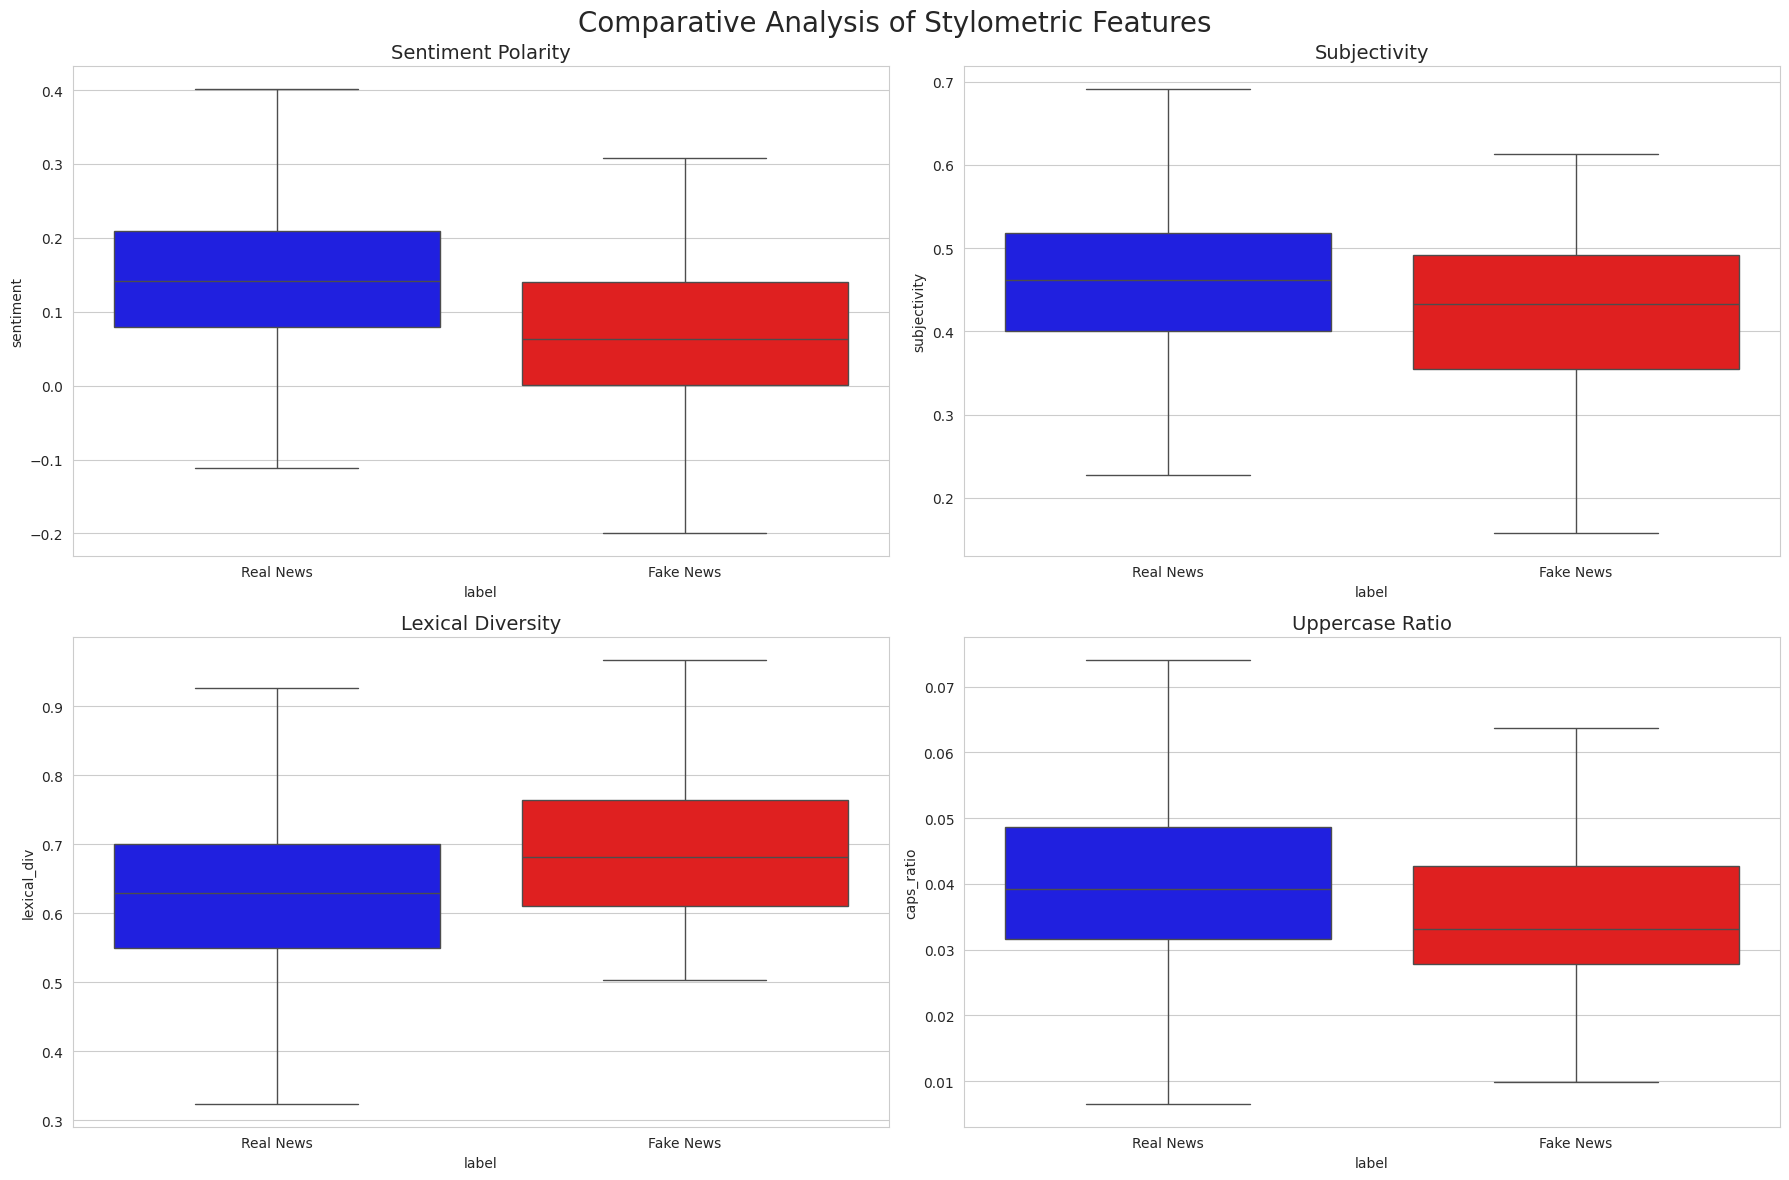

In [ ]:
 # BOX PLOTS

df['label'] = df['label'].astype(str)
custom_palette = {'0': 'blue', '1': 'red'}
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# sentiment plot
sns.boxplot(x='label', y='sentiment', data=df, ax=axes[0, 0], palette=custom_palette, showfliers=False)
axes[0, 0].set_title('Sentiment Polarity', fontsize=14)
axes[0, 0].set_xticklabels(['Real News', 'Fake News'])

# Subjectivity plot
sns.boxplot(x='label', y='subjectivity', data=df, ax=axes[0, 1], palette=custom_palette, showfliers=False)
axes[0, 1].set_title('Subjectivity', fontsize=14)
axes[0, 1].set_xticklabels(['Real News', 'Fake News'])

# Lexical diversity
sns.boxplot(x='label', y='lexical_div', data=df, ax=axes[1, 0], palette=custom_palette, showfliers=False)
axes[1, 0].set_title('Lexical Diversity', fontsize=14)
axes[1, 0].set_xticklabels(['Real News', 'Fake News'])

# Caps Ratio
sns.boxplot(x='label', y='caps_ratio', data=df, ax=axes[1, 1], palette=custom_palette, showfliers=False)
axes[1, 1].set_title('Uppercase Ratio', fontsize=14)
axes[1, 1].set_xticklabels(['Real News', 'Fake News'])

plt.suptitle('Comparative Analysis of Stylometric Features', fontsize=20)
plt.tight_layout()
plt.show()

We need to prove the mathematical difference between these values. So we will apply statistical t-test. So we will understand if there are some coincidences or not.

H0 : The means of fake and real groups are equal
H1 : Means are not equal, they are different

In [ ]:
# STATISTICAL T-TEST
from scipy import stats

features_to_test = ['sentiment', 'subjectivity', 'lexical_div', 'caps_ratio', 'word_count'] # defining quantitative features for hypothesis
results = [] # empty list

for feature in features_to_test:
    fake_data = df[df['label'] == '1'][feature]  # labeling fake data as 1
    real_data = df[df['label'] == '0'][feature]  # labeling real data as 0

    if len(fake_data) > 0 and len(real_data) > 0:  # validity check

        t_stat, p_val = stats.ttest_ind(fake_data, real_data)

        significance = "Meaningful difference exists" if p_val < 0.05 else "There is no difference"  # evaluating significance with p < 0.05

        results.append({
            'Feature': feature,
            'T-Statistic': round(t_stat, 4),
            'P-Value': p_val,                # probability of observing the data if H0 is true
            'Result': significance
        })

  # reporting results to dataframe
df_results = pd.DataFrame(results)
df_results.head()

,Feature,T-Statistic,P-Value,Result
0,sentiment,-7.6392,2.364999e-14,Meaningful difference exists
1,subjectivity,-6.1062,1.054302e-09,Meaningful difference exists
2,lexical_div,5.4943,4.009498e-08,Meaningful difference exists
3,caps_ratio,-0.8307,4.061811e-01,There is no difference
4,word_count,-3.7742,1.613555e-04,Meaningful difference exists


Here , we see except caps_ratio , pvalues are less than 0.05 so H0 hypothesis is denied. There are meaningful difference in terms of sentiment, subjectivity, lexical diversity and word count for our data. This is good news.

Lets display the source of top fake news from scraped articles using the source column we created.

In [ ]:
# SOURCE ANALYSIS
from urllib.parse import urlparse

def extract_domain(url):
    try:
        if pd.isna(url): return "unknown"

        domain = urlparse(url).netloc.replace('www.', '')

        return domain if domain else "unknown"
    except:
        return "unknown"

if 'source' not in df.columns:
    print("Extracting source domains from URLs...")
    df['source'] = df['news_url'].apply(extract_domain)
    df.loc[df['source'] == "", 'source'] = "unknown source"





Extracting source domains from URLs...


In [ ]:
fake_data = df[df['label'].astype(str) == '1']  # filtering the dataset for fake news


top_fake_sources = fake_data['source'].value_counts().head(15)

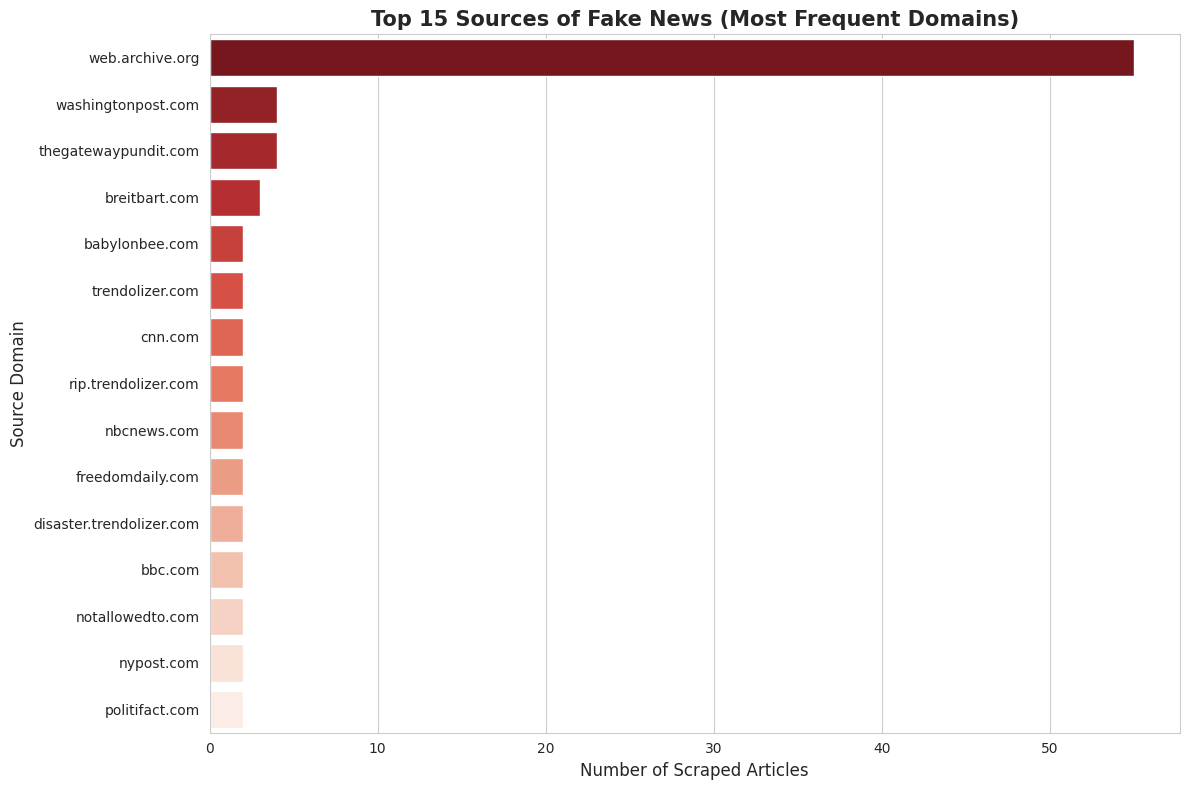


--- Top Fake News Sources Statistics ---
source
web.archive.org             55
washingtonpost.com           4
thegatewaypundit.com         4
breitbart.com                3
babylonbee.com               2
trendolizer.com              2
cnn.com                      2
rip.trendolizer.com          2
nbcnews.com                  2
freedomdaily.com             2
disaster.trendolizer.com     2
bbc.com                      2
notallowedto.com             2
nypost.com                   2
politifact.com               2
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x=top_fake_sources.values, y=top_fake_sources.index, palette='Reds_r')


plt.title('Top 15 Sources of Fake News (Most Frequent Domains)', fontsize=15, fontweight='bold')
plt.xlabel('Number of Scraped Articles', fontsize=12)
plt.ylabel('Source Domain', fontsize=12)

plt.tight_layout()
plt.show()

print("\n--- Top Fake News Sources Statistics ---")
print(top_fake_sources)

This time numbers are different from what we made at data manipulation part because we couldnt get all news from urls when scraping

Now , we can vectorize and carry our news to 2d. It allows us to differ fake and real news by visualizing 2d data. We need to have fake and real news seperate area so that our model will be better.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

In [ ]:
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')  # get the most important 3k words
X_tfidf = tfidf.fit_transform(df['full_text'].astype(str))  # transform text to numbers

In [ ]:
pca = PCA(n_components=2, random_state=42)  # carrying our data to second dimension (2D)
pca_result = pca.fit_transform(X_tfidf.toarray())

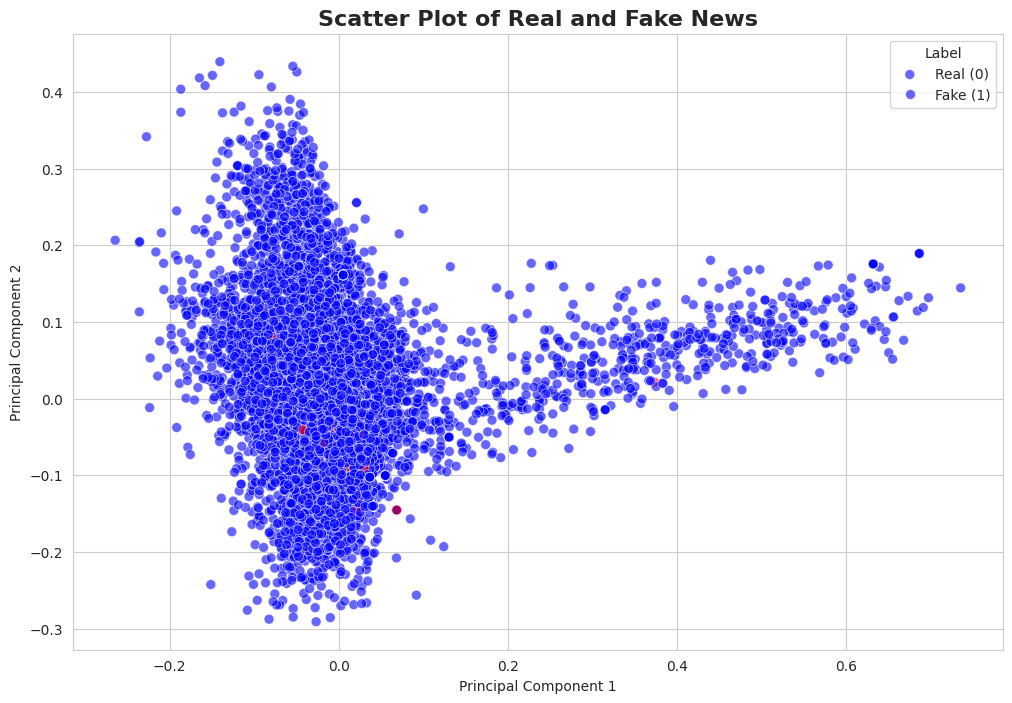

In [ ]:
# SCATTER PLOT

plt.figure(figsize=(12, 8))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=df['label'].astype(str),
                palette={'0':'blue', '1':'red'}, alpha=0.6, s=50)

plt.title('Scatter Plot of Real and Fake News', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Label', labels=['Real (0)', 'Fake (1)'])
plt.show()

It seems like fake news are camouflaged into the real news.

Also we should plot correlation matrix to understand relationships of our columns between them.

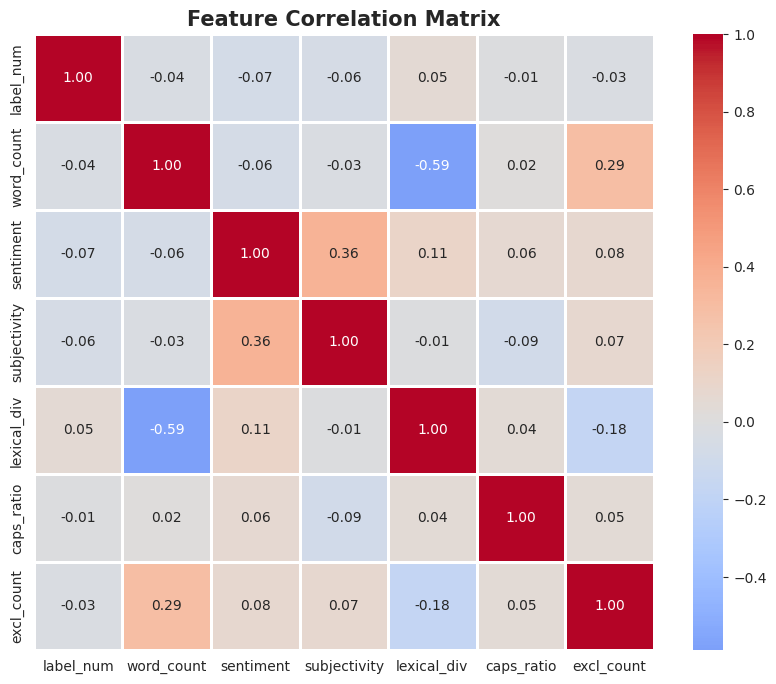

In [ ]:
# Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt
df['label_num'] = df['label'].astype(int)


corr_feats = ['label_num', 'word_count', 'sentiment', 'subjectivity', 'lexical_div', 'caps_ratio', 'excl_count']
corr_matrix = df[corr_feats].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.show()

There are no positive correlation at all. Only between sentiment and subjectivity (0.36) , means a new is not objective if there are some sentiment, makes sense. Lexical diversity and word count are negatively correlated (-0.59) , which means variety of words are descending if word count ascends, or otherwise.

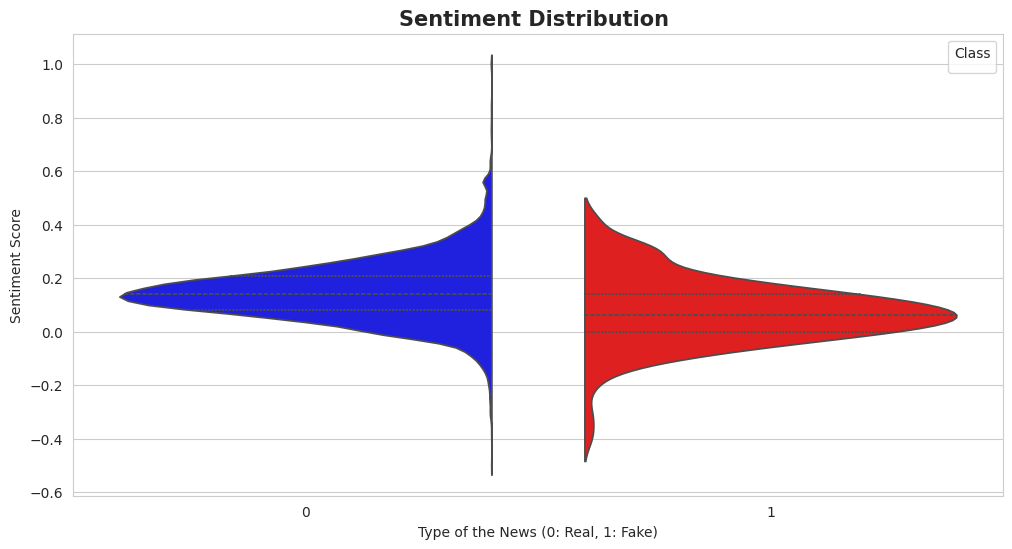

In [ ]:
# VIOLIN PLOT

df['label_str'] = df['label'].astype(int).astype(str)

plt.figure(figsize=(12, 6))
sns.violinplot(x='label_str', y='sentiment', hue='label_str', data=df,
               palette={'0':'blue', '1':'red'}, split=True, inner="quart")

plt.title('Sentiment Distribution ', fontsize=15, fontweight='bold')
plt.xlabel('Type of the News (0: Real, 1: Fake)')
plt.ylabel('Sentiment Score')
plt.legend(title='Class')
plt.show()

Violin plot shows both news have positive skew. But fake news are more widespread than real news. It has more variance.

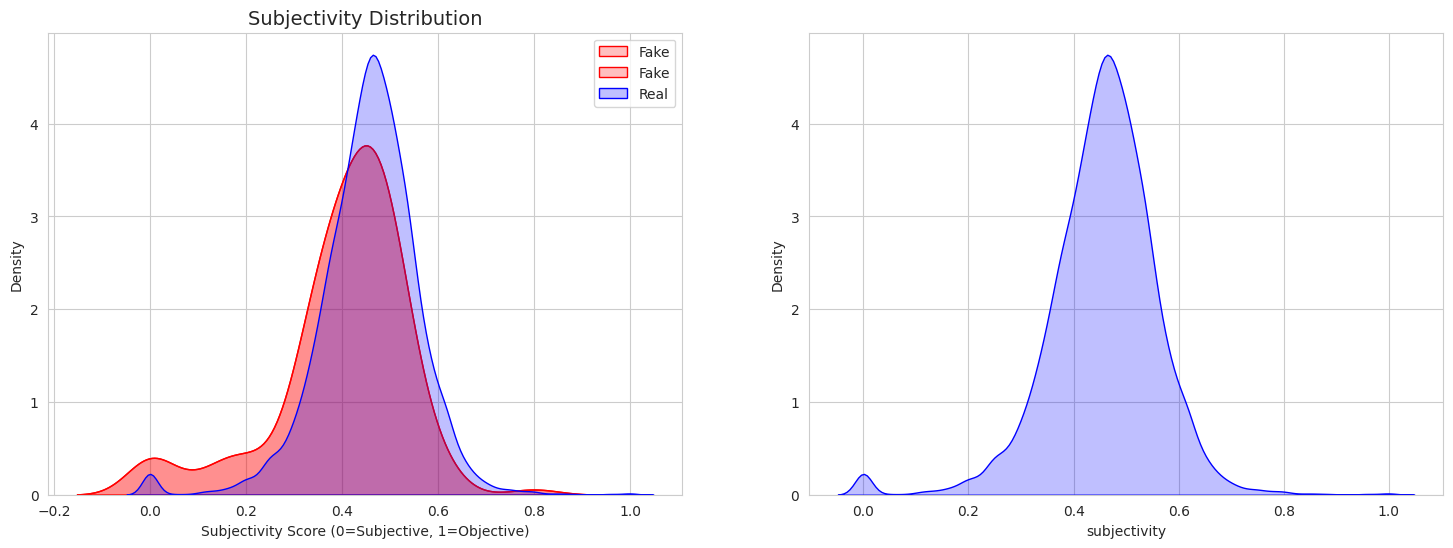

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.kdeplot(df[df['label']=='1']['subjectivity'], fill=True, color='red', label='Fake', ax=axes[0])
sns.kdeplot(df[df['label']=='0']['subjectivity'], fill=True, color='blue', label='Real', ax=axes[1])

sns.kdeplot(df[df['label']=='1']['subjectivity'], fill=True, color='red', label='Fake', ax=axes[0])
sns.kdeplot(df[df['label']=='0']['subjectivity'], fill=True, color='blue', label='Real', ax=axes[0])

axes[0].set_title('Subjectivity Distribution', fontsize=14)
axes[0].set_xlabel('Subjectivity Score (0=Subjective, 1=Objective)')
axes[0].legend()

We see that there are more fake news at lower subjectivity. And more real news at higher subjectivity.

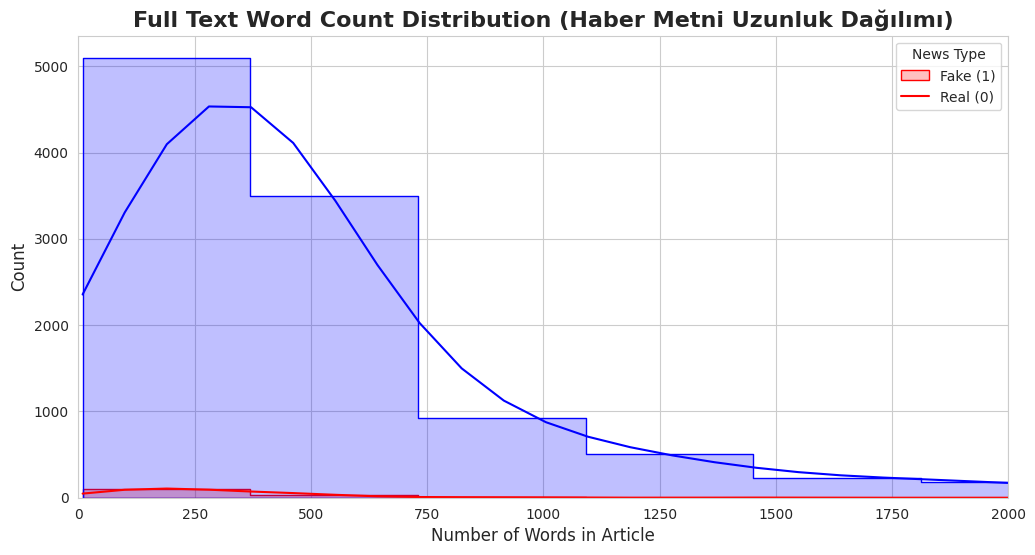


 Statistics of Word Count


         count        mean          std   min     25%    50%     75%      max
label                                                                        
0      10985.0  696.368776  1256.870198   9.0  234.00  395.0  651.00  18036.0
1        140.0  295.357143   222.744589  24.0  125.75  245.0  400.75   1449.0


In [ ]:
df['label'] = df['label'].astype(int)
if 'word_count' not in df.columns:
  target_col = 'full_text' if 'full_text' in df.columns else 'clean_title'
  df['word_count'] = df[target_col].fillna('').astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.histplot(data=df, x='word_count', hue='label', kde=True, element="step",
             palette={0:'blue', 1:'red'}, bins=50)

plt.title('Word Count Distribution ', fontsize=16, fontweight='bold')
plt.xlabel('Number of Words in Article', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.xlim(0, 2000) # x axis limit for graph

plt.legend(title='News Type', labels=['Fake (1)', 'Real (0)'])
plt.show()

  # printing statistics
print("\n Statistics of Word Count")
print("\n")
print(df.groupby('label')['word_count'].describe())

We see there is significant difference in terms of word_count between fake and real news. Average word count is lesser in fake news, actually we saw it before in data manipulation part but its our advantage to prove it again.

Since the amount of fake news are so small than real news, we may have to scrape another sources. This will be done from another notebook.

From now on, I will do external scraping in External_Scraping.ipynb. Then I will get updated csv and perform these visualizations again in Visualization2.ipynb . Sorry if it's been too long to read.